In [1]:
import mteb

# Load STS Benchmark task
tasks = mteb.get_tasks(tasks=["STSBenchmark"])

# Create evaluator
evaluator = mteb.MTEB(tasks=tasks)

# Load BGE-M3
model = mteb.get_model("BAAI/bge-m3")

# Run evaluation
results = evaluator.run(model)

print(results)

/tmp/ipykernel_8287/1723496745.py:7: DeprecationWarning: MTEB is deprecated and will be removed in future versions. Please use the `mteb.evaluate` function instead.
  evaluator = mteb.MTEB(tasks=tasks)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

───────────────────────────────────────────────── Selected tasks  ─────────────────────────────────────────────────

STS

- STSBenchmark, t2t

[TaskResult(task_name=STSBenchmark, main_score=0.85, scores=..., ...)]


In [3]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================
# 1. Load Dataset
# =========================

CSV_PATH = "/home/waleed/gard_test/embedding_test/English_semantic_similarity_dataset.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print(df.head())


# =========================
# 2. Load BGE-M3
# =========================

model = SentenceTransformer(
    "BAAI/bge-m3",
    device="cpu"
)
print("Model loaded successfully!")


# =========================
# 3. Generate Embeddings
# =========================

sentences1 = df["sentence1"].astype(str).tolist()
sentences2 = df["sentence2"].astype(str).tolist()

embeddings1 = model.encode(
    sentences1,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings2 = model.encode(
    sentences2,
    normalize_embeddings=True,
    show_progress_bar=True
)


# =========================
# 4. Calculate Cosine Similarity
# =========================

predicted_scores = np.sum(
    embeddings1 * embeddings2,
    axis=1
)


# =========================
# 5. Ground Truth
# =========================

true_scores = df["score"].values


# =========================
# 6. Evaluation Metrics
# =========================

spearman_score, spearman_p = spearmanr(
    true_scores,
    predicted_scores
)

pearson_score, pearson_p = pearsonr(
    true_scores,
    predicted_scores
)

mae = mean_absolute_error(
    true_scores,
    predicted_scores
)

mse = mean_squared_error(
    true_scores,
    predicted_scores
)

rmse = np.sqrt(mse)


# =========================
# 7. Print Results
# =========================

print("\n" + "=" * 50)
print("BGE-M3 Arabic Semantic Similarity Evaluation")
print("=" * 50)

print(f"Spearman Correlation : {spearman_score:.4f}")
print(f"Pearson Correlation  : {pearson_score:.4f}")
print(f"MAE                  : {mae:.4f}")
print(f"MSE                  : {mse:.4f}")
print(f"RMSE                 : {rmse:.4f}")

print("=" * 50)

Dataset shape: (569, 3)
                                           sentence1  \
0  Transformer architectures rely on self-attenti...   
1  Gradient checkpointing reduces GPU memory cons...   
2  Approximate nearest neighbor search significan...   
3  Normalization layers stabilize optimization by...   
4  Dynamic programming decomposes optimization pr...   

                                           sentence2  score  
0  Self-attention enables Transformer models to l...   0.96  
1  Caching every intermediate activation increase...   0.31  
2  Vector databases commonly employ approximate i...   0.94  
3  Batch normalization improves convergence by no...   0.91  
4  Greedy algorithms always produce globally opti...   0.18  


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded successfully!


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]


BGE-M3 Arabic Semantic Similarity Evaluation
Spearman Correlation : 0.5844
Pearson Correlation  : 0.6371
MAE                  : 0.2260
MSE                  : 0.0678
RMSE                 : 0.2603


In [8]:
import pandas as pd
df = pd.read_csv("/home/waleed/gard_test/embedding_test/CASS.csv")
df.head(5)

,Sentence 1,Sentence 2,Score,Category,Subcategory
0,تحدث الأعاصير المدارية في المناطق الاستوائية و...,الأعاصير المدارية تضرب المناطق الاستوائية وتلح...,5.00,جغرافيا,الظّواهر الطّبيعيّة
1,تحدث الأعاصير المدارية في المناطق الاستوائية و...,تضرب الأعاصير المدارية المناطق الاستوائية وتتس...,5.00,جغرافيا,الظّواهر الطّبيعيّة
2,تحدث الأعاصير المدارية في المناطق الاستوائية و...,الأعاصير المدارية تضرب المناطق الاستوائية وتسب...,4.67,جغرافيا,الظّواهر الطّبيعيّة
3,تحدث الأعاصير المدارية في المناطق الاستوائية و...,تحدث الأعاصير المدارية في المناطق الحارة وتؤدي...,4.00,جغرافيا,الظّواهر الطّبيعيّة
4,تحدث الأعاصير المدارية في المناطق الاستوائية و...,الأعاصير تضرب المناطق الساحلية وتؤدي إلى أضرار,3.00,جغرافيا,الظّواهر الطّبيعيّة


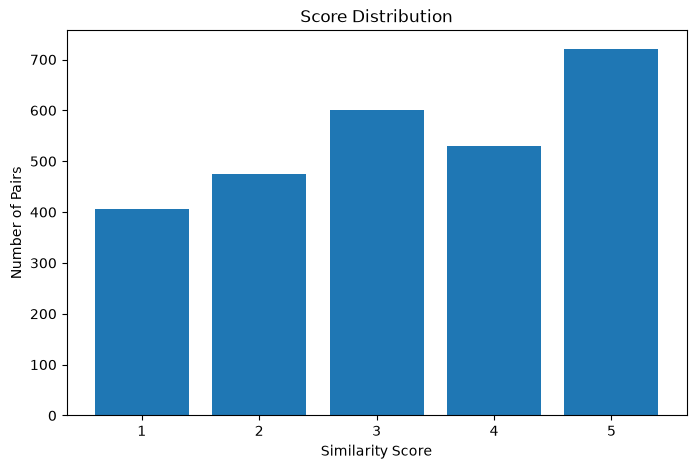

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["Score"],
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    rwidth=0.8
)

plt.xlabel("Similarity Score")
plt.ylabel("Number of Pairs")
plt.title("Score Distribution")

plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [6]:
print(df.columns.tolist())

['Sentence 1', 'Sentence 2', 'Score', 'Category', 'Subcategory']


In [7]:
print(df["Category"].unique())

<ArrowStringArray>
['جغرافيا', 'رياضة', 'جمل إنشائيّة', 'قانون', 'تاريخ', 'الصّحّة والطّبّ']
Length: 6, dtype: str


In [9]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================
# 1. Load Dataset
# =========================

CSV_PATH = "/home/waleed/gard_test/embedding_test/CASS.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print(df.head())


# =========================
# 2. Load BGE-M3
# =========================

model = SentenceTransformer(
    "BAAI/bge-m3",
    device="cpu"
)

print("Model loaded successfully!")


# =========================
# 3. Generate Embeddings
# =========================

sentences1 = df["Sentence 1"].astype(str).tolist()
sentences2 = df["Sentence 2"].astype(str).tolist()

embeddings1 = model.encode(
    sentences1,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings2 = model.encode(
    sentences2,
    normalize_embeddings=True,
    show_progress_bar=True
)


# =========================
# 4. Calculate Cosine Similarity
# =========================

predicted_scores = np.sum(
    embeddings1 * embeddings2,
    axis=1
)


# =========================
# 5. Ground Truth
# =========================

true_scores = df["Score"].values


# =========================
# 6. Evaluation Metrics
# =========================

spearman_score, spearman_p = spearmanr(
    true_scores,
    predicted_scores
)

pearson_score, pearson_p = pearsonr(
    true_scores,
    predicted_scores
)

mae = mean_absolute_error(
    true_scores,
    predicted_scores
)

mse = mean_squared_error(
    true_scores,
    predicted_scores
)

rmse = np.sqrt(mse)


# =========================
# 7. Print Results
# =========================

print("\n" + "=" * 50)
print("BGE-M3 Arabic Semantic Similarity Evaluation")
print("=" * 50)

print(f"Spearman Correlation : {spearman_score:.4f}")
print(f"Pearson Correlation  : {pearson_score:.4f}")
print(f"MAE                  : {mae:.4f}")
print(f"MSE                  : {mse:.4f}")
print(f"RMSE                 : {rmse:.4f}")

print("=" * 50)

Dataset shape: (3048, 5)
                                          Sentence 1  \
0  تحدث الأعاصير المدارية في المناطق الاستوائية و...   
1  تحدث الأعاصير المدارية في المناطق الاستوائية و...   
2  تحدث الأعاصير المدارية في المناطق الاستوائية و...   
3  تحدث الأعاصير المدارية في المناطق الاستوائية و...   
4  تحدث الأعاصير المدارية في المناطق الاستوائية و...   

                                          Sentence 2  Score Category  \
0  الأعاصير المدارية تضرب المناطق الاستوائية وتلح...   5.00  جغرافيا   
1  تضرب الأعاصير المدارية المناطق الاستوائية وتتس...   5.00  جغرافيا   
2  الأعاصير المدارية تضرب المناطق الاستوائية وتسب...   4.67  جغرافيا   
3  تحدث الأعاصير المدارية في المناطق الحارة وتؤدي...   4.00  جغرافيا   
4     الأعاصير تضرب المناطق الساحلية وتؤدي إلى أضرار   3.00  جغرافيا   

           Subcategory  
0  الظّواهر الطّبيعيّة  
1  الظّواهر الطّبيعيّة  
2  الظّواهر الطّبيعيّة  
3  الظّواهر الطّبيعيّة  
4  الظّواهر الطّبيعيّة  


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded successfully!


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

Batches:   0%|          | 0/96 [00:00<?, ?it/s]


BGE-M3 Arabic Semantic Similarity Evaluation
Spearman Correlation : 0.8139
Pearson Correlation  : 0.8147
MAE                  : 2.2234
MSE                  : 6.7510
RMSE                 : 2.5983


In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load BGE-M3 on CPU
model = SentenceTransformer(
    "BAAI/bge-m3",
    device="cpu"
)

# Two semantically similar Computer Science sentences
sentence1 = "The Amazon rainforest is one of the most biodiverse ecosystems on Earth."

sentence2 = "The Roman Empire developed an extensive network of roads connecting its major cities.he training loss."

# Generate embeddings
embeddings = model.encode(
    [sentence1, sentence2],
    normalize_embeddings=True
)

# Calculate cosine similarity
similarity = cosine_similarity(
    [embeddings[0]],
    [embeddings[1]]
)[0][0]

print("=" * 70)
print("Sentence 1:")
print(sentence1)

print("\nSentence 2:")
print(sentence2)

print("\nCosine Similarity:")
print(round(float(similarity), 4))

print("=" * 70)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Sentence 1:
The Amazon rainforest is one of the most biodiverse ecosystems on Earth.

Sentence 2:
The Roman Empire developed an extensive network of roads connecting its major cities.he training loss.

Cosine Similarity:
0.3535


In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "jinaai/jina-embeddings-v3-hf",
    trust_remote_code=True,
    device="cpu"
)

print("Jina loaded successfully!")

custom_st.py:   0%|          | 0.00/8.88k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v3-hf:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/192 [00:00<?, ?B/s]

Jina loaded successfully!


In [9]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

# =========================
# 1. Prepare sentences
# =========================

sentences1 = df["Sentence 1"].tolist()
sentences2 = df["Sentence 2"].tolist()

true_scores = df["Score"].astype(float).values

# =========================
# 2. Generate embeddings
# =========================

embeddings1 = model.encode(
    sentences1,
    task="text-matching",
    batch_size=4,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings2 = model.encode(
    sentences2,
    task="text-matching",
    batch_size=4,
    normalize_embeddings=True,
    show_progress_bar=True
)

# =========================
# 3. Cosine similarity
# =========================

predicted_scores = np.sum(
    embeddings1 * embeddings2,
    axis=1
)

# =========================
# 4. Evaluation
# =========================

spearman, _ = spearmanr(
    true_scores,
    predicted_scores
)

pearson, _ = pearsonr(
    true_scores,
    predicted_scores
)

print("=" * 50)
print("Jina Embeddings v3 - Arabic CASS Evaluation")
print("=" * 50)

print(f"Spearman : {spearman:.4f}")
print(f"Pearson  : {pearson:.4f}")

Batches:   0%|          | 0/762 [00:00<?, ?it/s]

Batches:   0%|          | 0/762 [00:00<?, ?it/s]

Jina Embeddings v3 - Arabic CASS Evaluation
Spearman : 0.7784
Pearson  : 0.7747
